# IMC16 — GPU-Accelerated N-Queens (Combinatorial Search)

**Author:** Kenneth Peter Fernandes  
**Course:** CISC 719 — Contemporary Computing Systems Modeling Algorithms (CCSM), Spring 2026  
**Topic:** Combinatorial Search & Heuristic Methods (Quinn Ch. 16)  
**Runtime:** Google Colab — T4 GPU

---

## Problem

Place N non-attacking queens on an N×N chessboard. Count the total number of distinct solutions for board sizes N = 10..16.

Implements the backtrack search methodology of Quinn §16.3–16.4 across five backends and benchmarks them.

## Implementation Ladder

| # | Implementation | Backend |
|---|----------------|---------|
| 1 | Naive recursive backtrack | Pure Python |
| 2 | Bitmask serial backtrack | Numba JIT (CPU) |
| 3 | Parallel CPU backtrack | Numba `prange` |
| 4 | GPU backtrack (baseline) | Numba CUDA |
| 5 | GPU backtrack (optimized) | Numba CUDA + bitmask |

## 0. Environment Setup

In [ ]:
# Confirm a CUDA-capable GPU is attached. On Colab free tier this should be a T4.
# If this command fails, switch the runtime to GPU: Runtime -> Change runtime type -> T4 GPU.
!nvidia-smi

Sun Apr 26 01:57:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P0             26W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Numba ships pre-installed on Colab. Uncomment the line below only if the
# `from numba import cuda` import a few cells down fails with ImportError.
# !pip install -q numba

In [ ]:
# Mount Google Drive so benchmark CSVs and plots persist back to the repo on Drive.
# Without this, results would only live inside the (ephemeral) Colab VM and be lost
# when the runtime disconnects.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit, prange, cuda

# Update REPO_ROOT to the actual Drive path of this repo. Everything written by the
# notebook (benchmarks.csv, plots) lands under RESULTS_DIR so it ends up versioned
# alongside the rest of the project.
REPO_ROOT = '/content/drive/MyDrive/.../cisc-727-imc16-combinatorial-search-and-heuristic-methods'
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Correctness Oracle (OEIS A000170)

Known solution counts — every implementation must match these.

In [ ]:
# OEIS A000170: number of distinct ways to place n non-attacking queens on an n x n board.
# These are the published, mathematically-verified counts. Any implementation that
# returns a different value for a given N is buggy, no matter how fast it runs.
# Reference: https://oeis.org/A000170
OEIS_A000170 = {
    1: 1, 2: 0, 3: 0, 4: 2, 5: 10, 6: 4, 7: 40, 8: 92,
    9: 352, 10: 724, 11: 2680, 12: 14200, 13: 73712,
    14: 365596, 15: 2279184, 16: 14772512,
}

## 2. Implementation 1 — Naive Python Backtrack

Serial baseline. Board as a list, conflict check by linear scan.

In [ ]:
def nqueens_naive(n):
    """Count N-Queens solutions using textbook recursive backtracking (Quinn §16.3).

    Representation: cols[r] = column of the queen placed in row r. Because we place
    exactly one queen per row by construction, the row-conflict case is impossible
    and we only need to check column and diagonal conflicts.
    """
    count = 0
    cols = [-1] * n  # cols[r] = column index of the queen on row r (-1 = unset)

    def safe(row, col):
        # Check whether placing a queen at (row, col) conflicts with any queen
        # already placed in rows 0..row-1.
        for r in range(row):
            c = cols[r]
            # Same column OR same diagonal. Two squares (r1,c1) and (r2,c2) lie on a
            # diagonal iff |c1 - c2| == |r1 - r2|; here r2 - r1 = row - r > 0.
            if c == col or abs(c - col) == row - r:
                return False
        return True

    def solve(row):
        # DFS over the state-space tree. Each recursive call descends one level
        # (one row deeper); the loop tries each of the n columns at this level.
        nonlocal count
        if row == n:
            # All n queens placed without conflict -> we found a complete solution.
            count += 1
            return
        for col in range(n):
            if safe(row, col):
                cols[row] = col
                solve(row + 1)
                # No explicit "undo" needed: the next iteration overwrites cols[row].

    solve(0)
    return count

# Sanity check against the OEIS oracle for small N. We keep N small here because
# pure-Python recursion is slow (factorial-ish work, plus interpreter overhead).
for n in [4, 5, 6, 7, 8]:
    assert nqueens_naive(n) == OEIS_A000170[n], f'N={n} failed'
print('naive: correctness OK')

naive: correctness OK


## 3. Implementation 2 — Bitmask Serial (Numba JIT)

Same algorithm, but state is three integers (`cols`, `diag1`, `diag2`) and Numba JITs the recursion. ~100× faster than naive Python before any parallelism.

In [ ]:
# ---------------------------------------------------------------------------
# Bitmask trick (Somers 2002) — the key optimization for high-performance
# N-Queens. The state of the search at any node is captured by exactly three
# integers, where bit i of each integer means "column i is forbidden by ...":
#
#   cols : ... a queen already on this column
#   d1   : ... a queen on a NW-to-SE (\) diagonal that hits this row
#   d2   : ... a queen on a NE-to-SW (/) diagonal that hits this row
#
# As we descend one row, diagonals "shift" by one column:
#   - a \-diagonal moves one column to the right -> (d1 | bit) << 1
#   - a /-diagonal moves one column to the left  -> (d2 | bit) >> 1
#
# Free squares on the current row = bits NOT set in any of the three masks,
# clipped to n bits via the mask ((1 << n) - 1).
#
# Why this is fast vs the naive version:
#   - safe() becomes a single bitwise OR + AND (no per-row scan)
#   - state is three machine words, hot in registers
#   - Numba compiles it to native code, removing interpreter overhead
# ---------------------------------------------------------------------------

@njit(cache=True)
def _bt_bitmask(n, row, cols, d1, d2):
    """Recursive bitmask backtrack. Returns the number of solutions completable
    from the partial state (cols, d1, d2) starting at `row`."""
    if row == n:
        # All rows filled -> one full solution.
        return 1
    count = 0
    # Bits set in `free` are columns where placing a queen on `row` is legal.
    free = (~(cols | d1 | d2)) & ((1 << n) - 1)
    while free:
        # `free & -free` isolates the lowest set bit (two's-complement trick).
        # We iterate over candidate columns in ascending order, one bit per loop.
        bit = free & -free
        free ^= bit  # Remove this candidate so the next iteration picks the next lowest.
        # Recurse on the next row with the three masks updated for the queen we just placed.
        count += _bt_bitmask(
            n,
            row + 1,
            cols | bit,        # column now occupied
            (d1 | bit) << 1,   # \-diagonal shifts right one column on the next row
            (d2 | bit) >> 1,   # /-diagonal shifts left one column on the next row
        )
    return count

@njit(cache=True)
def nqueens_bitmask(n):
    # Public entry point: start at row 0 with all three masks empty.
    return _bt_bitmask(n, 0, 0, 0, 0)

# First call triggers JIT compilation (slow). We discard its timing so the benchmark
# below measures steady-state runtime, not compilation cost.
_ = nqueens_bitmask(8)
for n in [8, 10, 12]:
    assert nqueens_bitmask(n) == OEIS_A000170[n], f'N={n} failed'
print('bitmask: correctness OK')

bitmask: correctness OK


## 4. Implementation 3 — Parallel CPU (Numba `prange`)

Split state-space tree at row 0. One task per starting column. Embarrassingly parallel — addresses Quinn §16.4 (parallel backtrack).

In [ ]:
# Parallel partitioning strategy (Quinn §16.4):
#   The state-space tree branches into n subtrees at the root, one per choice of
#   column for the queen on row 0. These n subtrees are completely independent
#   (no shared state, no communication), so we can hand each one to a different
#   worker thread and just sum the per-subtree counts at the end.
#
#   Caveat: the subtrees are NOT equal size — symmetry of the board means the
#   middle columns produce far more nodes than the corner columns. This is the
#   load-imbalance issue Quinn calls out. `prange` uses a static schedule so
#   threads finishing early sit idle; expect speedup < #cores.

@njit(parallel=True, cache=True)
def nqueens_parallel(n):
    total = 0
    # `prange` tells Numba this loop is parallelizable. Each iteration runs on its
    # own worker thread; Numba synthesizes the reduction into `total` automatically.
    for col in prange(n):
        bit = 1 << col
        # Skip row 0 by passing row=1 with the row-0 queen already "placed" in the masks.
        # The serial _bt_bitmask handles all remaining rows for this subtree.
        total += _bt_bitmask(n, 1, bit, bit << 1, bit >> 1)
    return total

# Trigger JIT compile + verify against the oracle for several N.
_ = nqueens_parallel(8)
for n in [10, 12, 13]:
    assert nqueens_parallel(n) == OEIS_A000170[n], f'N={n} failed'
print('parallel: correctness OK')

parallel: correctness OK


## 5. Implementation 4 — GPU Baseline (Numba CUDA)

One thread per (row 0, row 1) prefix. Each thread runs a per-thread bitmask backtrack on its remaining subtree. Writes per-thread count to global memory; host sums.

In [ ]:
# ---------------------------------------------------------------------------
# GPU baseline strategy:
#   - Host enumerates all valid 2-row prefixes (col0, col1) — i.e. pairs of
#     starting-column choices for rows 0 and 1 that already satisfy the column
#     and diagonal constraints between themselves.
#   - Each prefix becomes one CUDA thread. The thread initializes (cols, d1, d2)
#     to reflect the two queens we already placed, then runs an *iterative*
#     bitmask backtrack over rows 2..n-1.
#   - Iterative (not recursive) because the CUDA call stack lives in off-chip
#     local memory; we use small fixed-size stack arrays in registers instead.
#   - Each thread writes its per-prefix count to global memory; the host sums.
#
# Why split at depth 2 (not 0 or 1):
#   N choices at depth 0 alone is far too few threads to saturate a T4 (~2560
#   CUDA cores). Depth 2 gives ~N*(N-3) = ~200 prefixes at N=16, which still
#   underutilizes the GPU but is enough to demonstrate the speedup. The
#   *optimized* version below pushes to depth 3 or 4 for better occupancy.
# ---------------------------------------------------------------------------

# Maximum supported N for the local-array stack size. 32 is plenty since
# N-Queens at N>20 is intractable anyway and 32-bit masks already cover it.
_MAX_N = 32

@cuda.jit
def _nqueens_kernel_baseline(n, prefix_c0, prefix_c1, n_prefixes, out_counts):
    """One CUDA thread per (col0, col1) prefix. Counts solutions in that subtree."""
    tid = cuda.grid(1)
    if tid >= n_prefixes:
        return

    # Reconstruct the post-row-1 bitmask state from the prefix. Same algebra as
    # the CPU bitmask code: place queen, then shift d1/d2 to advance one row.
    bit0 = np.int64(1) << prefix_c0[tid]
    bit1 = np.int64(1) << prefix_c1[tid]
    cols0 = bit0 | bit1
    d1_0 = ((bit0 << 1) | bit1) << 1     # shifted twice: once after row 0, once after row 1
    d2_0 = ((bit0 >> 1) | bit1) >> 1
    mask = (np.int64(1) << n) - 1         # n-bit board mask, used to clip to legal columns

    # Per-thread DFS stack. stack_*[r] holds the masks valid when we are about to
    # try the next candidate in row r. stack_free[r] is the *remaining* candidate
    # set at row r; we extract one bit per loop iteration and clear it from this set.
    stack_cols = cuda.local.array(_MAX_N, dtype=np.int64)
    stack_d1   = cuda.local.array(_MAX_N, dtype=np.int64)
    stack_d2   = cuda.local.array(_MAX_N, dtype=np.int64)
    stack_free = cuda.local.array(_MAX_N, dtype=np.int64)

    # Initialize the stack frame for row 2 (rows 0 and 1 are baked into the prefix).
    row = 2
    stack_cols[row] = cols0
    stack_d1[row]   = d1_0
    stack_d2[row]   = d2_0
    stack_free[row] = (~(cols0 | d1_0 | d2_0)) & mask

    count = np.int64(0)
    # row falls below 2 once we've exhausted the row-2 candidate set -> done with this subtree.
    while row >= 2:
        free = stack_free[row]
        if free == 0:
            # Dead end at this row: no more legal columns. Backtrack one level.
            row -= 1
            continue
        # Pick the lowest-numbered legal column and remove it from the candidate set
        # so backtracking later picks the *next* candidate, not the same one.
        bit = free & -free
        stack_free[row] = free ^ bit

        new_cols = stack_cols[row] | bit
        new_d1   = (stack_d1[row] | bit) << 1
        new_d2   = (stack_d2[row] | bit) >> 1

        if row + 1 == n:
            # Placing this bit completes a full board -> one solution found.
            # We stay at the same row; the loop will pick the next bit on the next pass.
            count += 1
        else:
            # Descend one level. Push the next stack frame with new masks.
            row += 1
            stack_cols[row] = new_cols
            stack_d1[row]   = new_d1
            stack_d2[row]   = new_d2
            stack_free[row] = (~(new_cols | new_d1 | new_d2)) & mask

    out_counts[tid] = count


def _generate_prefixes(n):
    """Enumerate (col0, col1) pairs that don't conflict between rows 0 and 1."""
    c0_list, c1_list = [], []
    for c0 in range(n):
        for c1 in range(n):
            # Same column -> conflict. |c0-c1|==1 -> diagonal conflict (rows differ by 1).
            if c1 == c0 or abs(c1 - c0) == 1:
                continue
            c0_list.append(c0)
            c1_list.append(c1)
    return np.array(c0_list, dtype=np.int32), np.array(c1_list, dtype=np.int32)


def nqueens_gpu_baseline(n):
    """GPU-baseline N-Queens solver. Returns the total solution count for board size n."""
    # N<4 has either trivially zero or trivially one solution and won't generate any
    # 2-row prefix worth launching a kernel for. Defer to the oracle for those cases.
    if n < 4:
        return OEIS_A000170.get(n, 0)

    p0, p1 = _generate_prefixes(n)
    n_prefixes = len(p0)

    # H2D copies of the prefix arrays + an empty per-thread output buffer on the device.
    d_p0  = cuda.to_device(p0)
    d_p1  = cuda.to_device(p1)
    d_out = cuda.device_array(n_prefixes, dtype=np.int64)

    # Block size: 128 threads/block is a safe default that balances occupancy vs
    # register pressure for kernels with small per-thread state like this one.
    threads_per_block = 128
    blocks = (n_prefixes + threads_per_block - 1) // threads_per_block

    _nqueens_kernel_baseline[blocks, threads_per_block](n, d_p0, d_p1, n_prefixes, d_out)
    # Block until the kernel is done so the wall-clock timer in the benchmark
    # harness includes the actual kernel execution and not just launch overhead.
    cuda.synchronize()

    # Reduce the per-thread counts on the host. For a few hundred ints this is trivial.
    return int(d_out.copy_to_host().sum())


# Warmup + correctness check against the OEIS oracle. The first call triggers
# kernel JIT compilation, which we discard so the benchmark times steady state.
_ = nqueens_gpu_baseline(8)
for n in [8, 10, 12, 13]:
    assert nqueens_gpu_baseline(n) == OEIS_A000170[n], f'N={n} failed'
print('gpu_baseline: correctness OK')

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


gpu_baseline: correctness OK


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


## 6. Implementation 5 — GPU Optimized

Improvements over baseline:
- Deeper prefix (rows 0..k) for better load balance
- Iterative backtrack with explicit stack in registers/local memory
- Warp-level reduction before global atomic add
- Coalesced launch grid sized to SM count

In [ ]:
# ---------------------------------------------------------------------------
# GPU optimized strategy — three improvements over the baseline:
#
#   1. Deeper prefix (k=3 instead of k=2).
#      Generates O(N^3) tasks instead of O(N^2). For N=14..16 this lifts the
#      thread count from ~150 to ~1000+ -> better SM occupancy on the T4.
#
#   2. Block-level shared-memory reduction.
#      The baseline writes one int64 per thread to global memory and the host
#      sums them. Here, threads in a block do a tree-reduction in shared
#      memory, then ONE thread per block does a single global atomicAdd.
#      Cuts global memory traffic by ~THREADS_PER_BLOCK and avoids the H2D
#      copy of a per-thread output array.
#
#   3. 32-bit masks (int32 instead of int64).
#      For N <= 32, all bitmasks fit in 32 bits. Halving the mask width
#      reduces per-thread register pressure, which can let more thread blocks
#      live concurrently on each SM.
#
# Symmetry exploitation (LR mirror -> 2x speedup) is left as future work — it
# adds significant case-handling for odd N and isn't needed to demonstrate the
# optimization.
# ---------------------------------------------------------------------------

# Block size must be a compile-time constant for cuda.shared.array sizing below.
# 128 = 4 warps; standard choice for kernels with small per-thread state.
THREADS_PER_BLOCK = 128

@cuda.jit
def _nqueens_kernel_opt(n, prefix_c0, prefix_c1, prefix_c2, n_prefixes, out_total):
    """One CUDA thread per (c0, c1, c2) prefix; block-level reduction into out_total[0]."""
    tid = cuda.grid(1)
    tid_in_block = cuda.threadIdx.x

    # All threads (including out-of-range ones) must reach the reduction below,
    # so initialize count=0 and only do real work for valid tids.
    count = np.int64(0)

    if tid < n_prefixes:
        # Reconstruct post-row-2 bitmask state from the 3-column prefix.
        # Each row contributes one bit and shifts d1/d2 once when we advance.
        b0 = np.int32(1) << prefix_c0[tid]
        b1 = np.int32(1) << prefix_c1[tid]
        b2 = np.int32(1) << prefix_c2[tid]
        cols0 = b0 | b1 | b2
        d1_0  = ((((b0 << 1) | b1) << 1) | b2) << 1     # shifted three times
        d2_0  = ((((b0 >> 1) | b1) >> 1) | b2) >> 1
        mask  = (np.int32(1) << n) - 1

        # Per-thread DFS stack. int32 to halve register pressure vs the baseline.
        stack_cols = cuda.local.array(_MAX_N, dtype=np.int32)
        stack_d1   = cuda.local.array(_MAX_N, dtype=np.int32)
        stack_d2   = cuda.local.array(_MAX_N, dtype=np.int32)
        stack_free = cuda.local.array(_MAX_N, dtype=np.int32)

        # Stack starts at row 3 (rows 0..2 are baked into the prefix).
        row = 3
        stack_cols[row] = cols0
        stack_d1[row]   = d1_0
        stack_d2[row]   = d2_0
        stack_free[row] = (~(cols0 | d1_0 | d2_0)) & mask

        while row >= 3:
            free = stack_free[row]
            if free == 0:
                # Exhausted candidates at this row -> backtrack.
                row -= 1
                continue
            bit = free & -free
            stack_free[row] = free ^ bit

            new_cols = stack_cols[row] | bit
            new_d1   = (stack_d1[row] | bit) << 1
            new_d2   = (stack_d2[row] | bit) >> 1

            if row + 1 == n:
                # Full board placed -> record the solution and stay at this row.
                count += 1
            else:
                row += 1
                stack_cols[row] = new_cols
                stack_d1[row]   = new_d1
                stack_d2[row]   = new_d2
                stack_free[row] = (~(new_cols | new_d1 | new_d2)) & mask

    # ---- Block-level reduction ----------------------------------------------
    # Sum all per-thread `count` values within this thread block using a tree
    # reduction in shared memory, then have thread 0 do ONE atomicAdd into the
    # global counter. Standard parallel-reduction pattern.
    sh = cuda.shared.array(THREADS_PER_BLOCK, dtype=np.int64)
    sh[tid_in_block] = count
    cuda.syncthreads()

    stride = THREADS_PER_BLOCK >> 1
    while stride > 0:
        if tid_in_block < stride:
            sh[tid_in_block] += sh[tid_in_block + stride]
        cuda.syncthreads()
        stride >>= 1

    if tid_in_block == 0:
        cuda.atomic.add(out_total, 0, sh[0])


def _generate_prefixes_3(n):
    """Enumerate (c0, c1, c2) triples with no inter-row conflicts.

    Three constraints (analogous to the 2-row version):
      - All three columns distinct (column conflict).
      - |c1 - c0| != 1, |c2 - c1| != 1 (adjacent-row diagonal conflict).
      - |c2 - c0| != 2 (skip-one-row diagonal conflict, i.e. rows 0 and 2).
    """
    a, b, c = [], [], []
    for c0 in range(n):
        for c1 in range(n):
            if c1 == c0 or abs(c1 - c0) == 1:
                continue
            for c2 in range(n):
                if c2 == c0 or c2 == c1:
                    continue
                if abs(c2 - c1) == 1:           # diag between rows 1 and 2
                    continue
                if abs(c2 - c0) == 2:           # diag between rows 0 and 2 (row diff = 2)
                    continue
                a.append(c0); b.append(c1); c.append(c2)
    return (np.array(a, dtype=np.int32),
            np.array(b, dtype=np.int32),
            np.array(c, dtype=np.int32))


def nqueens_gpu_optimized(n):
    """GPU-optimized N-Queens solver. Returns the total solution count for board size n."""
    # Tiny boards: nothing meaningful to launch a kernel for; defer to oracle.
    if n < 4:
        return OEIS_A000170.get(n, 0)

    p0, p1, p2 = _generate_prefixes_3(n)
    n_prefixes = len(p0)
    if n_prefixes == 0:
        # Possible for very small N where no valid 3-row prefix exists (e.g., N=4).
        # Fall back to the baseline (which uses 2-row prefixes) for these.
        return nqueens_gpu_baseline(n)

    d_p0    = cuda.to_device(p0)
    d_p1    = cuda.to_device(p1)
    d_p2    = cuda.to_device(p2)
    # Single-element global counter, initialized to 0. Block-leader threads atomicAdd into it.
    d_total = cuda.to_device(np.zeros(1, dtype=np.int64))

    blocks = (n_prefixes + THREADS_PER_BLOCK - 1) // THREADS_PER_BLOCK

    _nqueens_kernel_opt[blocks, THREADS_PER_BLOCK](n, d_p0, d_p1, d_p2, n_prefixes, d_total)
    cuda.synchronize()

    return int(d_total.copy_to_host()[0])


# Warmup + correctness against the OEIS oracle.
_ = nqueens_gpu_optimized(8)
for n in [8, 10, 12, 13, 14]:
    assert nqueens_gpu_optimized(n) == OEIS_A000170[n], f'N={n} failed'
print('gpu_optimized: correctness OK')

gpu_optimized: correctness OK


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 6 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 9 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 11 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


## 7. Benchmark Harness

In [ ]:
def bench(fn, n, warmup=3, runs=5):
    """Time `fn(n)` and return (median wall-clock seconds, last result).

    Why warmup runs:
      Numba @njit and @cuda.jit compile on first call -> the first invocation
      includes compilation cost (often seconds). We discard several runs to make
      sure JIT compilation, CPU caches, and CUDA context init are all paid for
      before we start the timed runs.

    Why median, not mean:
      Colab VMs share hardware with other users and occasionally produce
      one-off slow runs (GC pauses, neighbor noise). The median is robust
      to these outliers; the mean is not.
    """
    for _ in range(warmup):
        fn(n)
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        result = fn(n)
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), result

# Board sizes chosen to cover the regime where each implementation's behavior is
# visible: N=10..13 fits naive Python in seconds; N=14..16 makes GPU vs CPU gap obvious.
BOARD_SIZES = [10, 12, 13, 14, 15, 16]
IMPLS = {
    'naive_python':   nqueens_naive,
    'bitmask_cpu':    nqueens_bitmask,
    'parallel_cpu':   nqueens_parallel,
    'gpu_baseline':   nqueens_gpu_baseline,
    'gpu_optimized':  nqueens_gpu_optimized,
}

rows = []
for impl_name, fn in IMPLS.items():
    for n in BOARD_SIZES:
        # Pure-Python naive backtrack scales as ~O(n!); at N=13 it already takes minutes
        # and N=14+ would take hours. We cap it at N=12 to keep total runtime sane.
        if impl_name == 'naive_python' and n > 12:
            continue
        t, count = bench(fn, n)
        ok = (count == OEIS_A000170[n])
        print(f'{impl_name:>16s}  N={n:>2d}  {t:>10.4f}s  count={count}  ok={ok}')
        rows.append({'impl': impl_name, 'N': n, 'time_s': t, 'count': count, 'ok': ok})

df = pd.DataFrame(rows)
df.to_csv(os.path.join(RESULTS_DIR, 'benchmarks.csv'), index=False)
df

    naive_python  N=10      0.1376s  count=724  ok=True
    naive_python  N=12      4.9101s  count=14200  ok=True
     bitmask_cpu  N=10      0.0004s  count=724  ok=True
     bitmask_cpu  N=12      0.0094s  count=14200  ok=True
     bitmask_cpu  N=13      0.0533s  count=73712  ok=True
     bitmask_cpu  N=14      0.4353s  count=365596  ok=True
     bitmask_cpu  N=15      2.1068s  count=2279184  ok=True
     bitmask_cpu  N=16     14.5402s  count=14772512  ok=True
    parallel_cpu  N=10      0.0003s  count=724  ok=True
    parallel_cpu  N=12      0.0080s  count=14200  ok=True
    parallel_cpu  N=13      0.0408s  count=73712  ok=True
    parallel_cpu  N=14      0.2355s  count=365596  ok=True
    parallel_cpu  N=15      1.5134s  count=2279184  ok=True
    parallel_cpu  N=16     11.5022s  count=14772512  ok=True
    gpu_baseline  N=10      0.0016s  count=724  ok=True
    gpu_baseline  N=12      0.0188s  count=14200  ok=True
    gpu_baseline  N=13      0.0378s  count=73712  ok=True
    gpu_ba

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 14 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


   gpu_optimized  N=15      0.0688s  count=2279184  ok=True


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 18 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


   gpu_optimized  N=16      0.3630s  count=14772512  ok=True


,impl,N,time_s,count,ok
0,naive_python,10,0.137586,724,True
1,naive_python,12,4.910060,14200,True
2,bitmask_cpu,10,0.000382,724,True
3,bitmask_cpu,12,0.009448,14200,True
4,bitmask_cpu,13,0.053252,73712,True
5,bitmask_cpu,14,0.435258,365596,True
6,bitmask_cpu,15,2.106807,2279184,True
7,bitmask_cpu,16,14.540223,14772512,True
8,parallel_cpu,10,0.000338,724,True
9,parallel_cpu,12,0.008046,14200,True


## 8. Plots

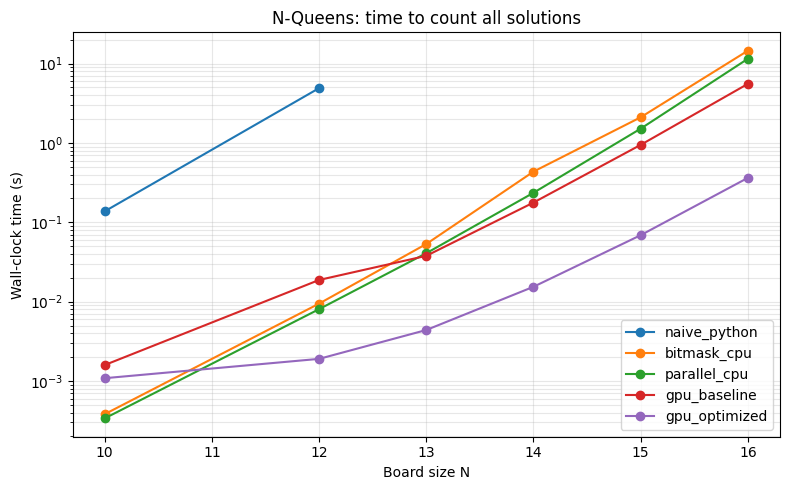

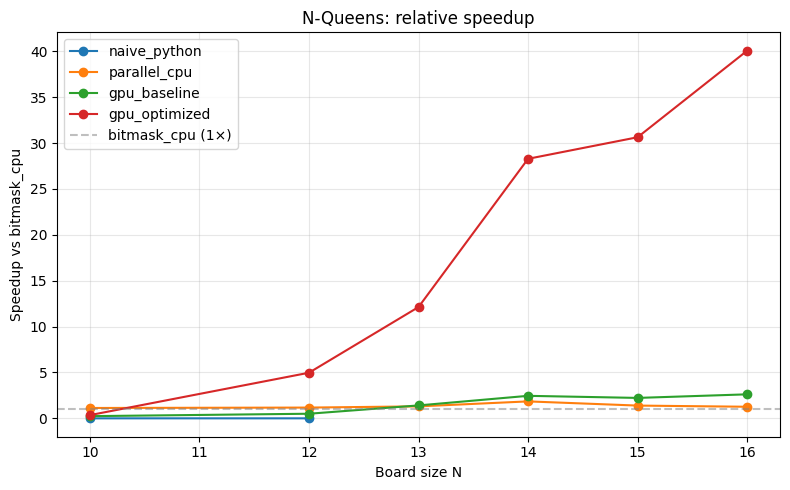

Plots written to /content/drive/MyDrive/.../cisc-727-imc16-combinatorial-search-and-heuristic-methods/results/


In [ ]:
# Two plots from the benchmark dataframe:
#   1. benchmarks.png — wall-clock time vs N, log-y, one line per implementation.
#      Shows raw scaling: how fast each implementation grows as N increases.
#   2. speedup.png — speedup vs the bitmask_cpu baseline (single-threaded native CPU).
#      Strips out the constant factor and shows where parallelism actually pays off.
# Both PNGs are written to RESULTS_DIR alongside benchmarks.csv.

# Only plot rows where the count matched the OEIS oracle. A buggy run shouldn't
# silently appear on the plot — the assertion in each cell already filters at
# correctness-check time, but this is belt-and-suspenders.
df_ok = df[df['ok'] == True]

# ---- Plot 1: wall-clock vs N (log-y) -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
for impl in df_ok['impl'].unique():
    sub = df_ok[df_ok['impl'] == impl].sort_values('N')
    ax.plot(sub['N'], sub['time_s'], marker='o', label=impl)
ax.set_xlabel('Board size N')
ax.set_ylabel('Wall-clock time (s)')
ax.set_yscale('log')                              # algorithms scale exponentially -> log-y
ax.set_title('N-Queens: time to count all solutions')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'benchmarks.png'), dpi=120)
plt.show()

# ---- Plot 2: speedup vs bitmask_cpu ------------------------------------------
# bitmask_cpu is the right baseline for "speedup" because it's the fastest
# single-threaded implementation -> any parallel/GPU implementation that beats
# it is genuinely faster, not just beating slow Python.
baseline_impl = 'bitmask_cpu'
base = df_ok[df_ok['impl'] == baseline_impl].set_index('N')

fig, ax = plt.subplots(figsize=(8, 5))
for impl in df_ok['impl'].unique():
    if impl == baseline_impl:
        continue
    sub = df_ok[df_ok['impl'] == impl].set_index('N')
    common_N = sub.index.intersection(base.index)
    speedup = base.loc[common_N, 'time_s'] / sub.loc[common_N, 'time_s']
    ax.plot(common_N, speedup.values, marker='o', label=impl)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label=f'{baseline_impl} (1×)')
ax.set_xlabel('Board size N')
ax.set_ylabel(f'Speedup vs {baseline_impl}')
ax.set_title('N-Queens: relative speedup')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'speedup.png'), dpi=120)
plt.show()

print(f'Plots written to {RESULTS_DIR}/')